In [ ]:
import tensorflow as tf
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt
import cv2
from tqdm import tqdm
print( tf.__version__)

2.19.0


In [ ]:

(x_train, y_train), (x_test, y_test) = cifar10.load_data()

# norm pixel values
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

#one hot encoding
y_train = tf.keras.utils.to_categorical(y_train, 10)
y_test = tf.keras.utils.to_categorical(y_test, 10)

print("Training data shape:", x_train.shape)
print("Training labels shape:", y_train.shape)
print("Test data shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 15s 0us/step
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000, 10)
Test data shape: (10000, 32, 32, 3)


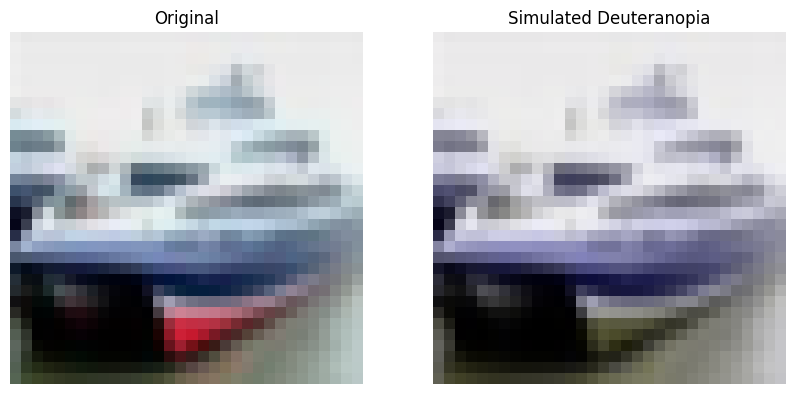

In [ ]:
'''take normal image in rgb
   convert to lms
   apply filter to simulate missing green cone
   convert back to rgb
   fix pixel values to [0,1]
   return new simulated image'''



# non differentiable soln(eval and visual)
def simulate_cvd_deuteranopia(rgb_img):
    # rgb to lms conv matrix(Eq 1a)
    rgb2lms = np.array([[17.8824, 43.5161, 4.11935],
                        [3.45565, 27.1554, 3.86714],
                        [0.0299566, 0.184309, 1.46709]])
    # lms to rgb conv matrix
    lms2rgb = np.linalg.inv(rgb2lms)
    # deut simulation matrix (eq 2a from paper)
    cvd_deuteranope = np.array([[1, 0, 0],
                                [0.494207, 0, 1.24827],
                                [0, 0, 1]])

    # image to lms
    lms_img = np.dot(rgb_img, rgb2lms.T)
    # apply filter
    simulated_lms = np.dot(lms_img, cvd_deuteranope.T)
    # back to rgb
    simulated_rgb = np.dot(simulated_lms, lms2rgb.T)
    # force again all values to [0,1]
    simulated_rgb = np.clip(simulated_rgb, 0, 1)
    return simulated_rgb




# differntiable soln(for train)
@tf.function
def tf_simulate_cvd_deuteranopia(rgb_img_batch):
    # conv matrix for rgb to lms
    rgb2lms = tf.constant([[17.8824, 43.5161, 4.11935],
                           [3.45565, 27.1554, 3.86714],
                           [0.0299566, 0.184309, 1.46709]], dtype=tf.float32)
    #lms to rgb
    lms2rgb = tf.constant(np.linalg.inv([[17.8824, 43.5161, 4.11935],
                                        [3.45565, 27.1554, 3.86714],
                                        [0.0299566, 0.184309, 1.46709]]), dtype=tf.float32)

    cvd_filter = tf.constant([[1, 0, 0],
                             [0.494207, 0, 1.24827],
                             [0, 0, 1]], dtype=tf.float32)

    # reshape image for batch,h,w,3 to batch*h*w,3 for applying matrix mul
    original_shape = tf.shape(rgb_img_batch)
    flattened = tf.reshape(rgb_img_batch, [-1, 3])

    # transform to lms
    lms = tf.tensordot(flattened, rgb2lms, axes=[[1], [1]])
    # apply filter
    simulated_lms = tf.tensordot(lms, cvd_filter, axes=[[1], [1]])
    # back to rgb
    simulated_rgb = tf.tensordot(simulated_lms, lms2rgb, axes=[[1], [1]])
    # clip to 0,1
    simulated_rgb = tf.reshape(simulated_rgb, original_shape)
    return tf.clip_by_value(simulated_rgb, 0.0, 1.0)

# test
img_index = 1
original_img = x_test[img_index]
cvd_img = simulate_cvd_deuteranopia(original_img)

plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.title("Original")
plt.imshow(original_img)
plt.axis('off')

plt.subplot(1, 2, 2)
plt.title("Simulated Deuteranopia")
plt.imshow(cvd_img)
plt.axis('off')
plt.show()

In [ ]:
'''refree acts like judge, tells whether the img after correction is recognisable.
used as a guide to train the corrector so corrected images are not only realisitc but also classifiable'''

# refree model(img classifier)
def build_referee_model(input_shape=(32, 32, 3), num_classes=10):
    model = models.Sequential([
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D((2, 2)),#downsample by half
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.Flatten(),#1d for dense layers
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ])
    return model

'''corrector tries to fix color blind img to more distinguishable colour since input
image is distorted output is corrected'''

# corrector model(imf to img transformer)
def build_corrector_model(input_shape=(32, 32, 3)):
    inputs = layers.Input(shape=input_shape)
    x = layers.Conv2D(16, (3, 3), padding='same')(inputs)
    x = layers.ReLU()(x)
    x = layers.Conv2D(16, (3, 3), padding='same')(x)
    x = layers.ReLU()(x)
    outputs = layers.Conv2D(3, (3, 3), activation='sigmoid', padding='same')(x)
    model = models.Model(inputs, outputs)
    return model

# Instantiate the models
referee = build_referee_model()
corrector = build_corrector_model()

# Print model summaries
print("Referee Model Summary:")
referee.summary()
print("\nCorrector Model Summary:")
corrector.summary()

Referee Model Summary:


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

...

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 32, 32, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 32, 32, 16)     │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu (ReLU)                    │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 32, 32, 16)     │         2,320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ re_lu_1 (ReLU)                  │ (None, 32, 32, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 32, 32, 3)      │           435 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,203 (12.51 KB)

 Trainable params: 3,203 (12.51 KB)

 Non-trainable params: 0 (0.00 B)

Training the Referee model...
Epoch 1/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 76s 95ms/step - accuracy: 0.3218 - loss: 1.8234 - val_accuracy: 0.5190 - val_loss: 1.3246
Epoch 2/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 72s 92ms/step - accuracy: 0.5430 - loss: 1.2810 - val_accuracy: 0.5914 - val_loss: 1.1461
Epoch 3/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 88ms/step - accuracy: 0.6107 - loss: 1.1156 - val_accuracy: 0.6156 - val_loss: 1.0810
Epoch 4/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 92ms/step - accuracy: 0.6471 - loss: 1.0023 - val_accuracy: 0.6571 - val_loss: 1.0102
Epoch 5/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 81s 91ms/step - accuracy: 0.6772 - loss: 0.9266 - val_accuracy: 0.6698 - val_loss: 0.9587
Epoch 6/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 71s 91ms/step - accuracy: 0.7074 - loss: 0.8453 - val_accuracy: 0.6875 - val_loss: 0.9061
Epoch 7/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 85s 95ms/step - accuracy: 0.7255 - loss: 0.7867 - val_accuracy: 0.6973 - val_loss: 0.8876
Epoch 8/15
782/782 ━━━━━━━━━━━━━━━━━━━━ 79s 92ms/step - accu

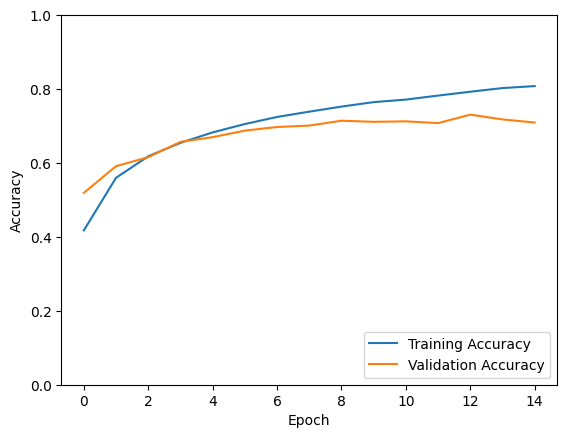

In [ ]:
# compile refree
referee.compile(optimizer='adam',
                loss='categorical_crossentropy',
                metrics=['accuracy'])

# train ref on original imgs
print("Training the Referee model...")
history = referee.fit(x_train, y_train,
                      epochs=15,
                      batch_size=64,
                      validation_data=(x_test, y_test))

referee.save_weights('referee_cifar10.weights.h5')


plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label = 'Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0, 1])
plt.legend(loc='lower right')
plt.show()

In [ ]:
'''load ref weights
  freeze ref
  set optimizer and loss for corrector
  create dataset batches
'''

#load pre trained refree weights
referee.load_weights('referee_cifar10.weights.h5')
referee.trainable = False  #freeze ref weights
corrector_optimizer = tf.keras.optimizers.Adam(learning_rate=1e-4)
loss_fn = tf.keras.losses.CategoricalCrossentropy()
# dataset creation
train_dataset = tf.data.Dataset.from_tensor_slices((x_train, y_train)).batch(128).shuffle(1000) # Increased batch size for Colab GPU

# training step for corrector
@tf.function
def train_corrector_step(images, labels):
    with tf.GradientTape() as tape:
        # forward pass: correct -> simulate cvd -> classify
        corrected_imgs = corrector(images, training=True)
        simulated_imgs = tf_simulate_cvd_deuteranopia(corrected_imgs)
        predictions = referee(simulated_imgs, training=False)
        loss = loss_fn(labels, predictions) #loss based on refrees error
    # calc gradients update corrector
    gradients = tape.gradient(loss, corrector.trainable_variables)
    corrector_optimizer.apply_gradients(zip(gradients, corrector.trainable_variables))
    return loss

# training loop
epochs = 10
for epoch in range(epochs):
    print(f"\nEpoch {epoch+1}/{epochs}")
    epoch_losses = []
    for batch_images, batch_labels in tqdm(train_dataset, desc="Training"):
        loss = train_corrector_step(batch_images, batch_labels)
        epoch_losses.append(loss.numpy())

    avg_loss = np.mean(epoch_losses)
    print(f"Average Loss: {avg_loss:.4f}")

# final corrector model
corrector.save('deuteranopia_corrector.h5')
print("Corrector training complete and model saved!")


Epoch 1/10


Training: 100%|██████████| 391/391 [02:30<00:00,  2.60it/s]


Average Loss: 3.3674

Epoch 2/10


Training: 100%|██████████| 391/391 [02:26<00:00,  2.66it/s]


Average Loss: 1.6065

Epoch 3/10


...

Average Loss: 0.7944

Epoch 9/10


Training: 100%|██████████| 391/391 [02:17<00:00,  2.85it/s]


Average Loss: 0.7616

Epoch 10/10


Training: 100%|██████████| 391/391 [02:15<00:00,  2.88it/s]


Average Loss: 0.7340
Corrector training complete and model saved!


Generating evaluation images...
16/16 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
Calculating accuracies...

--- Final Quantitative Results ---
Referee Accuracy on Original Images: 0.7040
Referee Accuracy on CVD Images (Baseline): 0.6640
Referee Accuracy on Corrected->CVD Images (Ours): 0.6780

--- Qualitative Results ---


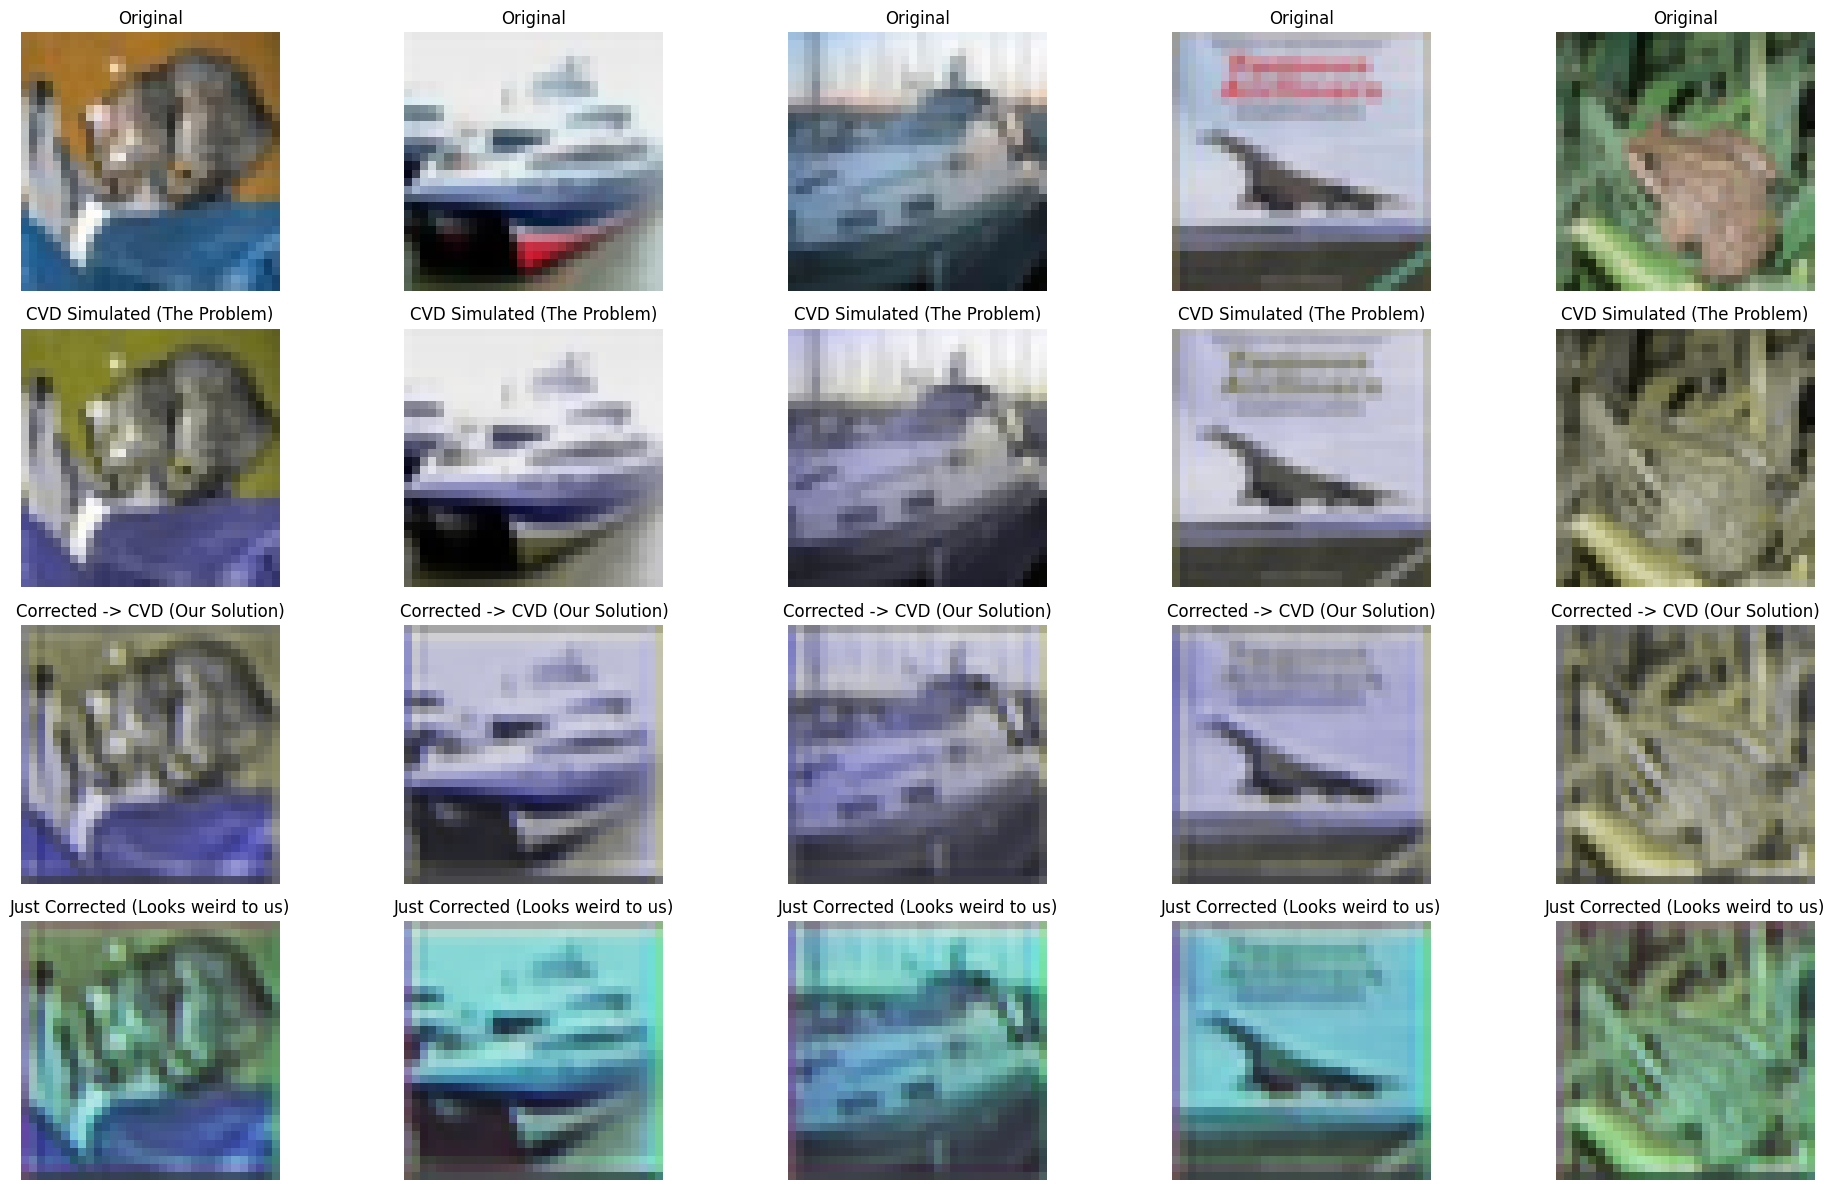

In [ ]:

print("Generating evaluation images...")
x_test_cvd = np.array([simulate_cvd_deuteranopia(img) for img in x_test[:500]]) # Use a subset for speed
x_test_corrected = corrector.predict(x_test[:500])
x_test_corrected_then_simulated = np.array([simulate_cvd_deuteranopia(img) for img in x_test_corrected])

print("Calculating accuracies...")
_, acc_original = referee.evaluate(x_test[:500], y_test[:500], verbose=0)
_, acc_cvd = referee.evaluate(x_test_cvd, y_test[:500], verbose=0)
_, acc_corrected = referee.evaluate(x_test_corrected_then_simulated, y_test[:500], verbose=0)

print(f"\n--- Final Quantitative Results ---")
print(f"Referee Accuracy on Original Images: {acc_original:.4f}")
print(f"Referee Accuracy on CVD Images (Baseline): {acc_cvd:.4f}")
print(f"Referee Accuracy on Corrected->CVD Images (Ours): {acc_corrected:.4f}")

print("\n--- Qualitative Results ---")
n = 5
plt.figure(figsize=(20, 12))
for i in range(n):
    # orig
    plt.subplot(4, n, i+1)
    plt.imshow(x_test[i])
    plt.title('Original')
    plt.axis('off')
    # cvd simulated
    plt.subplot(4, n, i+1 + n)
    plt.imshow(x_test_cvd[i])
    plt.title('CVD Simulated (The Problem)')
    plt.axis('off')
    # corrected -> cvd simulated
    plt.subplot(4, n, i+1 + 2*n)
    plt.imshow(x_test_corrected_then_simulated[i])
    plt.title('Corrected -> CVD (Our Solution)')
    plt.axis('off')
    #just corrected
    plt.subplot(4, n, i+1 + 3*n)
    plt.imshow(x_test_corrected[i])
    plt.title('Just Corrected (Looks weird to us)')
    plt.axis('off')
plt.tight_layout()
plt.show()